# 1. Kesifsel Veri Analizi (EDA) - Trafo Bazli Elektrik Tuketim Tahmini

**Yarisma:** Gdz ve Adm Elektrik trafo bazli gunluk elektrik tuketimini tahmin etme.
**Metrik:** RMSLE (Root Mean Squared Logarithmic Error)

Bu notebook, veri setinin yapisini, dagilimlarini, mevsimselligini ve modelleme oncesi
dikkat edilmesi gereken onemli noktalari (uc degerler, duzensiz raporlama, yeni trafolar)
inceler.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (11, 4.5)
sns.set_style('whitegrid')

DATA_DIR = '../data'  # train.csv / test.csv / sample_submission.csv burada olmali


In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

train['tarih'] = pd.to_datetime(train['tarih'])
test['tarih'] = pd.to_datetime(test['tarih'])
train['tanim'] = train['tanim'].astype(str)
test['tanim'] = test['tanim'].astype(str)

print('Train:', train.shape)
print('Test :', test.shape)
train.head()


Train: (1226237, 5)
Test : (714688, 5)


,tanim,guc,tarih,tuketim,lokasyon
0,70122340,1000,2025-01-01,5789.76,İZMİR>METROPOL>KARABAĞLAR
1,70142184,1250,2025-01-01,602.40,İZMİR>METROPOL>KARABAĞLAR
2,77540173,50,2025-01-01,19.92,MANİSA>GÖRDES
3,77540175,100,2025-01-01,25.64,MANİSA>GÖRDES
4,77540199,50,2025-01-01,10.98,MANİSA>GÖRDES


## 1.1 Temel Bilgiler

In [3]:
print(f"Train tarih araligi : {train.tarih.min().date()} -> {train.tarih.max().date()}  ({train.tarih.nunique()} gun)")
print(f"Test  tarih araligi : {test.tarih.min().date()} -> {test.tarih.max().date()}  ({test.tarih.nunique()} gun)")
print(f"Train benzersiz trafo (tanim): {train.tanim.nunique()}")
print(f"Test  benzersiz trafo (tanim): {test.tanim.nunique()}")

new_tanim = set(test.tanim) - set(train.tanim)
print(f"\nTest'te olup train'de HIC olmayan trafo sayisi: {len(new_tanim)}  ({len(new_tanim)/test.tanim.nunique():.1%})")
print("\nEksik deger (train):"); print(train.isna().sum())


Train tarih araligi : 2025-01-01 -> 2026-03-31  (455 gun)
Test  tarih araligi : 2026-04-01 -> 2026-07-31  (122 gun)
Train benzersiz trafo (tanim): 5344
Test  benzersiz trafo (tanim): 7036



Test'te olup train'de HIC olmayan trafo sayisi: 2024  (28.8%)

Eksik deger (train):
tanim       0
guc         0
tarih       0
tuketim     0
lokasyon    0
dtype: int64


**Onemli:** Test setindeki trafolarin yaklasik **%29**'u train setinde hic gorulmemis.
Bu, modelin sadece gecmis trafo davranisina degil, **guc (guc) + lokasyon bazli genel
kaliplara** da guvenmesi gerektigi anlamina gelir.

## 1.2 Lokasyon Yapisi

In [4]:
def split_lok(df):
    parts = df['lokasyon'].str.split('>', expand=True)
    df['il'] = parts[0]
    df['bolge'] = parts[1]
    df['ilce'] = parts[2] if parts.shape[1] > 2 else parts[1]
    df['ilce'] = df['ilce'].fillna(df['bolge'])
    return df

train = split_lok(train)
test = split_lok(test)

print("Iller:", train.il.unique())
print("Il bazinda trafo sayisi:")
print(train[['tanim','il']].drop_duplicates().il.value_counts())
print(f"\nBenzersiz ilce/bolge sayisi: {train.ilce.nunique()}")


Iller: <ArrowStringArray>
['İZMİR', 'MANİSA']
Length: 2, dtype: str
Il bazinda trafo sayisi:
il
İZMİR     4015
MANİSA    1329
Name: count, dtype: int64

Benzersiz ilce/bolge sayisi: 47


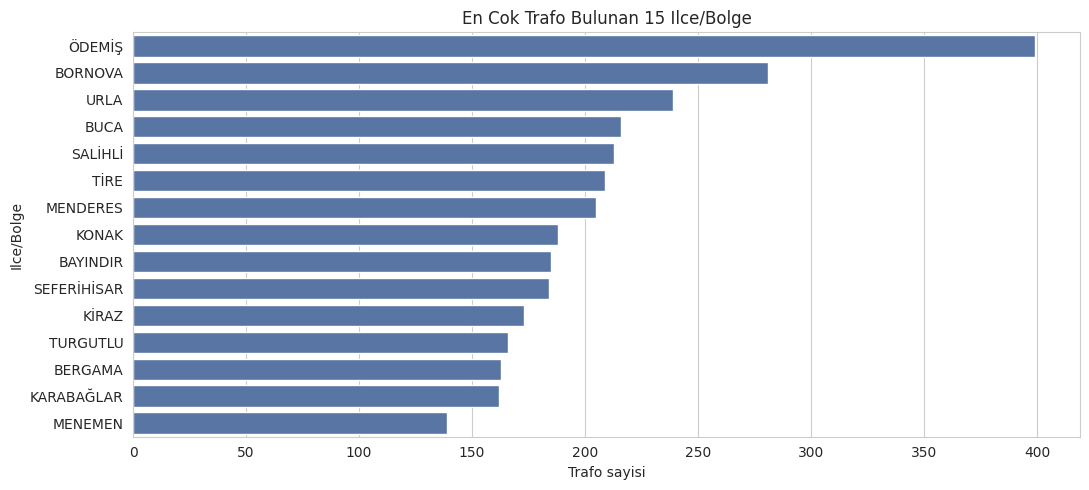

In [5]:
loc_counts = train[['tanim','ilce']].drop_duplicates().ilce.value_counts().head(15)
plt.figure(figsize=(11,5))
sns.barplot(x=loc_counts.values, y=loc_counts.index, color='#4C72B0')
plt.xlabel('Trafo sayisi'); plt.ylabel('Ilce/Bolge')
plt.title('En Cok Trafo Bulunan 15 Ilce/Bolge')
plt.tight_layout(); plt.show()


## 1.3 Tuketim Dagilimi

In [6]:
print(train.tuketim.describe())
print("\nPercentile'lar:")
print(train.tuketim.quantile([0.01,0.25,0.5,0.75,0.9,0.99,0.999]))
print(f"\nSifir tuketim sayisi: {(train.tuketim==0).sum()}")
print(f"Negatif tuketim sayisi: {(train.tuketim<0).sum()}")


count    1.226237e+06
mean     3.251897e+03
std      1.687821e+05
min      0.000000e+00
25%      2.604900e+02
50%      1.075200e+03
75%      2.748480e+03
max      5.040305e+07
Name: tuketim, dtype: float64

Percentile'lar:
0.010         0.0000
0.250       260.4900
0.500      1075.2000
0.750      2748.4800
0.900      5063.6800
0.990     14655.0032
0.999    163685.8296
Name: tuketim, dtype: float64

Sifir tuketim sayisi: 57536
Negatif tuketim sayisi: 0


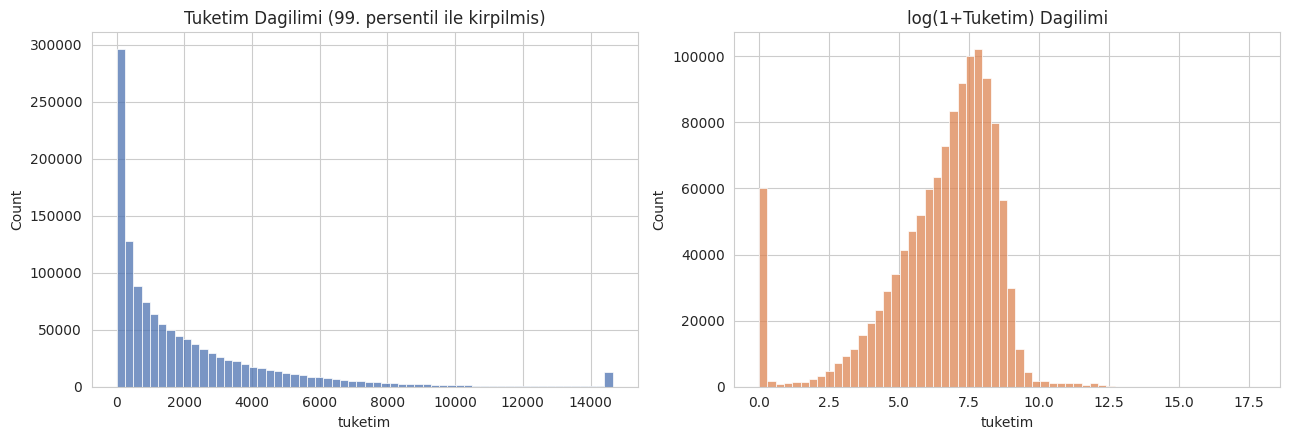

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(train.tuketim.clip(upper=train.tuketim.quantile(0.99)), bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tuketim Dagilimi (99. persentil ile kirpilmis)')
sns.histplot(np.log1p(train.tuketim), bins=60, ax=axes[1], color='#DD8452')
axes[1].set_title('log(1+Tuketim) Dagilimi')
plt.tight_layout(); plt.show()


Tuketim dagilimi ciddi sekilde saga carpik (log-normal benzeri) - bu tam olarak
**RMSLE**'nin var olma sebebi: kucuk ve buyuk trafolari ayni terazide tartmak icin
log olcek gerekiyor. Bu yuzden modelleme hedefini `log1p(tuketim)` olarak sececegiz.

## 1.4 Uc Degerler (Outliers)

In [8]:
# En buyuk 10 tuketim degeri
train.nlargest(10, 'tuketim')[['tanim','guc','tarih','tuketim','ilce']]


,tanim,guc,tarih,tuketim,ilce
1106137,75010709,35800,2026-01-26,50403051.0,KARABAĞLAR
790748,75010709,35800,2026-02-10,48324398.4,KARABAĞLAR
837676,75020108,35800,2025-07-12,45631701.0,KONAK
917916,75020108,35800,2025-08-16,45407230.2,KONAK
499994,75010304,35800,2025-12-25,45155642.4,KONAK
581529,75090407,35800,2026-01-30,45028999.8,BAYRAKLI
242303,75020108,35800,2026-02-13,44765323.2,KONAK
943531,75020108,35800,2025-12-17,44303837.4,KONAK
275331,75020108,35800,2025-11-14,43551806.4,KONAK
76186,75020108,35800,2025-11-04,43518355.2,KONAK


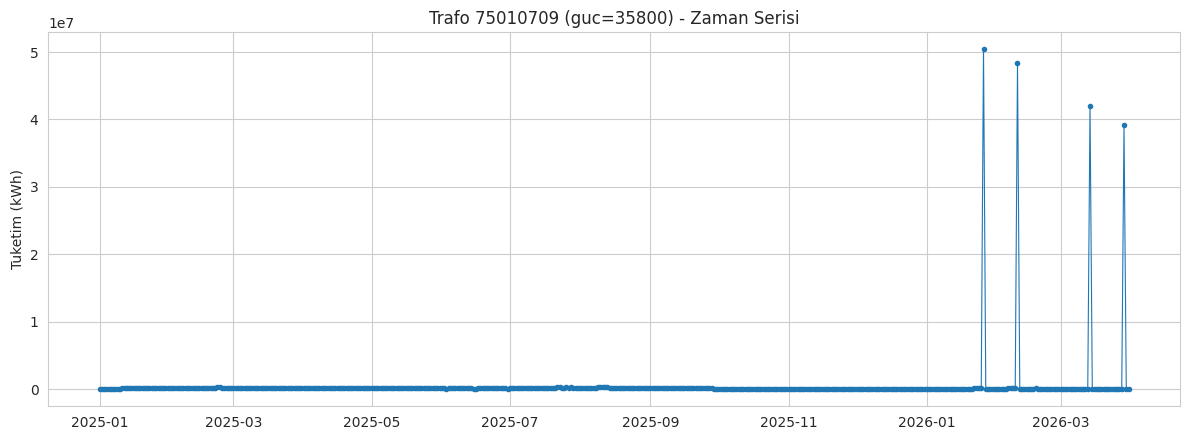

count    4.550000e+02
mean     5.220720e+05
std      4.213921e+06
min      0.000000e+00
25%      2.070000e+04
50%      1.450656e+05
75%      2.162529e+05
max      5.040305e+07
Name: tuketim, dtype: float64

>1M kWh olan gun sayisi: 4 / 455


In [9]:
# Ornek: cok buyuk bir trafonun zaman serisi - nadir uc degerler gercek mi, hata mi?
example_tanim = train.nlargest(1, 'tuketim').tanim.values[0]
sub = train[train.tanim == example_tanim].sort_values('tarih')

plt.figure(figsize=(12,4.5))
plt.plot(sub.tarih, sub.tuketim, marker='o', markersize=3, linewidth=0.8)
plt.title(f'Trafo {example_tanim} (guc={sub.guc.iloc[0]}) - Zaman Serisi')
plt.ylabel('Tuketim (kWh)')
plt.tight_layout(); plt.show()

print(sub.tuketim.describe())
print(f"\n>1M kWh olan gun sayisi: {(sub.tuketim>1_000_000).sum()} / {len(sub)}")


Bu trafo normalde ~100-200 bin kWh civarinda tuketiyor, ama **nadir gunlerde**
(452 gunden sadece birkacinda) normalin 100-300 kati bir deger goruluyor - muhtemelen
olcum/veri girisi hatasi. Bu tur uc degerler, **ham ortalama tabanli feature'lari**
ciddi sekilde bozabilir; bu yuzden feature engineering'de `log1p` donusum + medyan/
winsorize edilmis istatistikler tercih edilecek.

## 1.5 Mevsimsellik - Aylik ve Haftalik Oruntuler

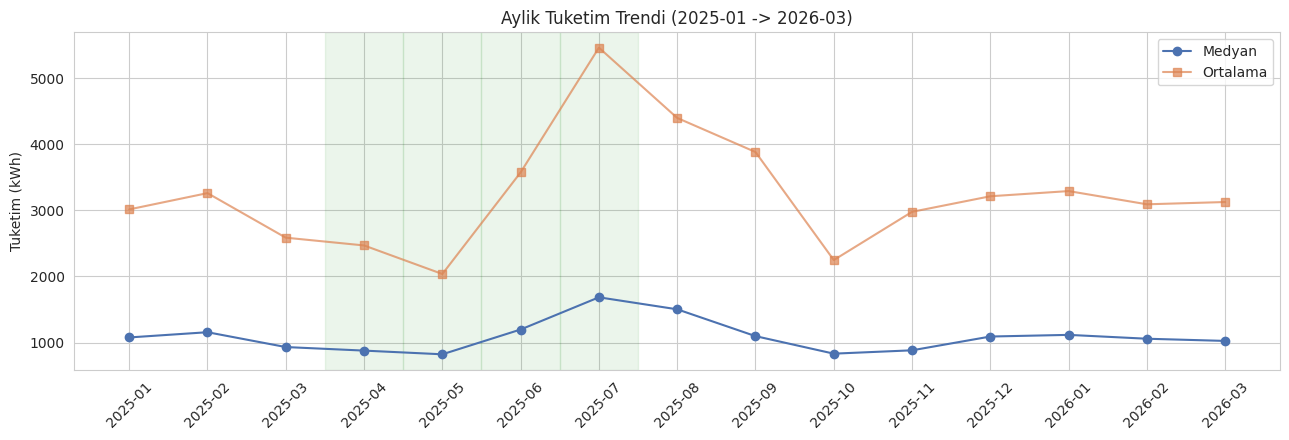

            ortalama   medyan  kayit_sayisi
tarih                                      
2025-01  3013.168659  1076.76         64027
2025-02  3259.592372  1155.84         58267
2025-03  2585.589502   931.64         65206
2025-04  2468.196311   877.76         64048
2025-05  2036.343450   821.90         67262
2025-06  3573.244313  1196.80         67976
2025-07  5459.246940  1683.76         75643
2025-08  4396.277358  1502.34         79680
2025-09  3880.936840  1096.72         73499
2025-10  2246.962530   831.60         79399
2025-11  2976.385637   882.18         87154
2025-12  3211.995309  1090.62        105889
2026-01  3290.340782  1115.70        112546
2026-02  3090.348826  1057.36        104875
2026-03  3124.791400  1024.26        120766


In [10]:
monthly = train.groupby(train.tarih.dt.to_period('M')).agg(
    ortalama=('tuketim','mean'), medyan=('tuketim','median'), kayit_sayisi=('tuketim','count'))
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(monthly.index, monthly['medyan'], marker='o', label='Medyan', color='#4C72B0')
ax.plot(monthly.index, monthly['ortalama'], marker='s', label='Ortalama', color='#DD8452', alpha=0.7)
ax.set_title('Aylik Tuketim Trendi (2025-01 -> 2026-03)')
ax.set_ylabel('Tuketim (kWh)')
ax.legend()
plt.xticks(rotation=45)
for m in ['2025-04','2025-05','2025-06','2025-07']:
    if m in monthly.index:
        idx = list(monthly.index).index(m)
        ax.axvspan(idx-0.5, idx+0.5, color='green', alpha=0.08)
plt.tight_layout(); plt.show()
print(monthly)


**Kritik bulgu:** Belirgin bir yaz mevsimselligi var - **Mayis en dusuk**, **Temmuz
zirve** (yaklasik 2 kat fark). Yesil ile isaretli aylar (Nisan-Temmuz 2025), test
doneminin (Nisan-Temmuz 2026) bir onceki yilki karsiligi. Model bu yukselen trendi
dogru yakalayabilmeli - bu muhtemelen en onemli tek sinyal.

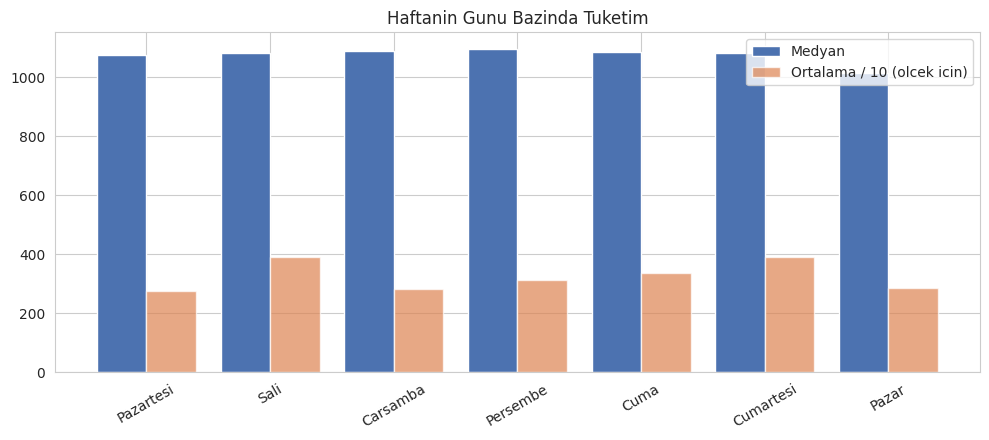

In [11]:
dow_names = ['Pazartesi','Sali','Carsamba','Persembe','Cuma','Cumartesi','Pazar']
dow = train.groupby(train.tarih.dt.dayofweek).agg(ortalama=('tuketim','mean'), medyan=('tuketim','median'))
dow.index = dow_names

fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(dow))
ax.bar(x-0.2, dow['medyan'], width=0.4, label='Medyan', color='#4C72B0')
ax.bar(x+0.2, dow['ortalama']/10, width=0.4, label='Ortalama / 10 (olcek icin)', color='#DD8452', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(dow.index, rotation=30)
ax.set_title('Haftanin Gunu Bazinda Tuketim')
ax.legend()
plt.tight_layout(); plt.show()


Medyan bazinda haftanin gunleri arasinda belirgin bir fark yok - asil guclu sinyal
**aylik/mevsimsel** duzeyde. Ortalama degerlerdeki dalgalanma buyuk olcude birkac uc
degerli trafodan kaynaklaniyor (bkz. 1.4).

## 1.6 Trafo Kapasitesi (guc) ve Raporlama Duzeni

In [12]:
print("guc dagilimi (train):"); print(train.guc.describe())
print("\nguc dagilimi (test):"); print(test.guc.describe())

guc_var = train.groupby('tanim')['guc'].nunique()
print(f"\nBirden fazla guc degeri olan trafo sayisi: {(guc_var>1).sum()} / {len(guc_var)}  (guc pratikte sabit bir kapasite feature'i)")


guc dagilimi (train):
count    1.226237e+06
mean     8.114253e+02
std      2.792940e+03
min      4.000000e+01
25%      2.500000e+02
50%      4.000000e+02
75%      1.000000e+03
max      3.590000e+04
Name: guc, dtype: float64

guc dagilimi (test):
count    714688.000000
mean        682.366650
std        1959.859967
min          40.000000
25%         250.000000
50%         400.000000
75%        1000.000000
max       35900.000000
Name: guc, dtype: float64

Birden fazla guc degeri olan trafo sayisi: 0 / 5344  (guc pratikte sabit bir kapasite feature'i)


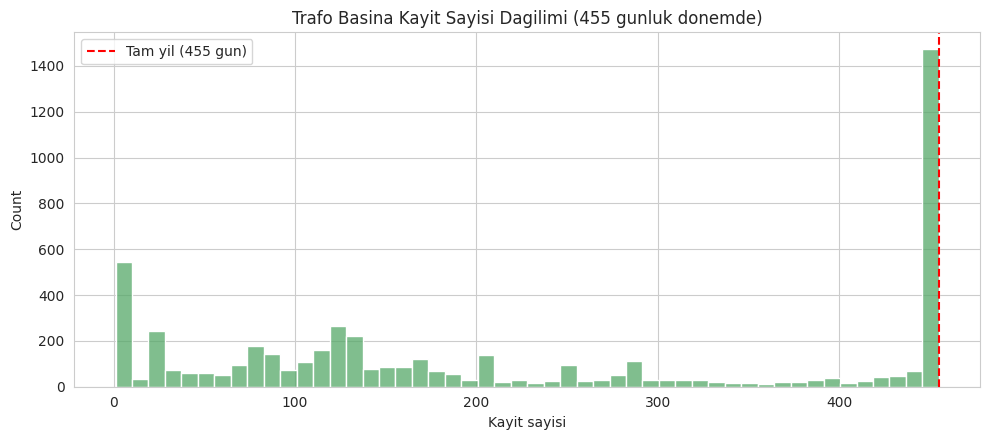

count    5344.000000
mean      229.460516
std       171.546547
min         1.000000
25%        82.000000
50%       170.000000
75%       453.000000
max       455.000000
dtype: float64


In [13]:
counts_per_tanim = train.groupby('tanim').size()
plt.figure(figsize=(10,4.5))
sns.histplot(counts_per_tanim, bins=50, color='#55A868')
plt.axvline(train.tarih.nunique(), color='red', linestyle='--', label=f'Tam yil ({train.tarih.nunique()} gun)')
plt.title('Trafo Basina Kayit Sayisi Dagilimi (455 gunluk donemde)')
plt.xlabel('Kayit sayisi'); plt.legend()
plt.tight_layout(); plt.show()
print(counts_per_tanim.describe())


**Onemli:** Panel dengesiz - medyan trafo, 455 gunden sadece ~170'inde kayit
birakmis. Yani her trafo icin duzenli gunluk seri yok; bazi trafolarda uzun boslukar
(gap) var. Bu, "bir onceki gunun degeri" gibi feature'larin kirilgan olacagi, bunun
yerine **"en son bilinen deger" + "o degerin ne kadar eski oldugu"** yaklasiminin daha
saglam olacagi anlamina gelir.

## 1.7 Trafolarin Ilk/Son Gorulme Tarihleri

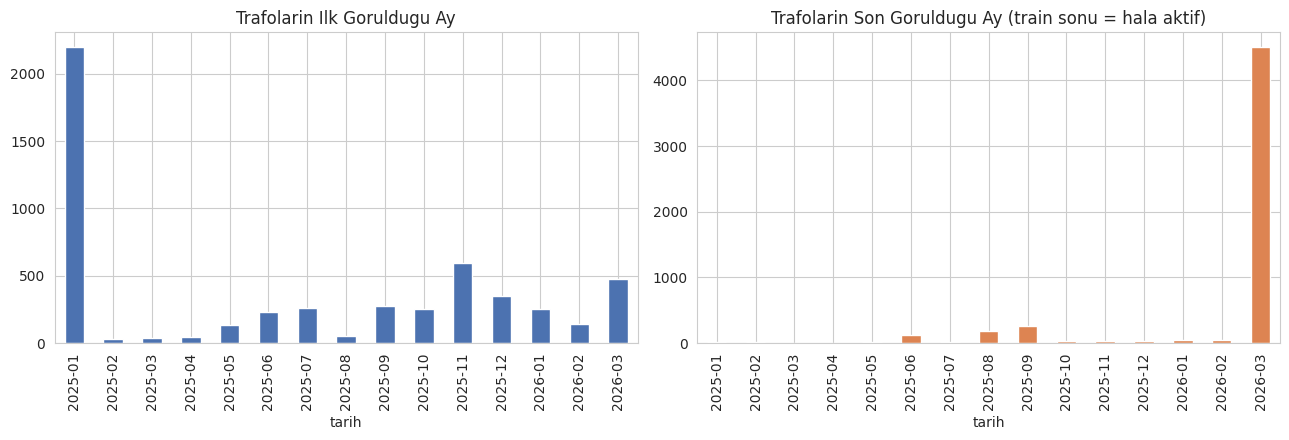

In [14]:
first_seen = train.groupby('tanim')['tarih'].min()
last_seen = train.groupby('tanim')['tarih'].max()

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
first_seen.dt.to_period('M').value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Trafolarin Ilk Goruldugu Ay')
last_seen.dt.to_period('M').value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Trafolarin Son Goruldugu Ay (train sonu = hala aktif)')
plt.tight_layout(); plt.show()


Trafolarin buyuk cogunlugu train'in son ayinda (Mart 2026) hala aktif - yani
churn (kaybolma) dusuk, veri setine zamanla yeni trafolar ekleniyor. Bu da test
setindeki yeni trafolarin normal bir devamlilik oldugunu, anomali olmadigini gosteriyor.

## 1.8 Ozet - Feature Engineering'i Yonlendiren Bulgular

1. **Guclu yaz mevsimselligi** -> aylik/mevsimsel feature'lar sart, ozellikle Nisan-Temmuz.
2. **Test'in %29'u yeni trafo** -> guc + ilce bazli fallback (yedek) istatistikler gerekli.
3. **Uc degerler ham ortalamayi bozuyor** -> `log1p` donusum + medyan/winsorize tabanli istatistikler.
4. **Duzensiz raporlama (gap'ler)** -> basit "bir onceki gun" yerine "en son bilinen deger + yasi (recency)".
5. **Test 122 gun ileriye donuk ve gunluk geri bildirim yok** -> feature'lar gunluk
   guncellenen degil, **tahmin anindaki (kesim tarihi) bilgiyle donmus** olmali - bu,
   sonraki notebook'ta detaylandirilan en kritik tasarim karari.

Devami: `02_feature_engineering.ipynb`